# Reconstruciton of DOSY NMR signals

### Pierre Aguié, Darius Dabert

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# Reconstruction of DOSY NMR signals - Part I

## Generation of synthetic data

### Question 1

In [3]:
x_true = np.array([2.0440461e-15, 9.5346375e-15, 4.2731280e-14, 1.8399916e-13, 7.6122670e-13, 3.0258013e-12, 1.1555667e-11, 4.2401169e-11, 1.4948199e-10, 5.0632357e-10, 1.6477664e-09, 5.1521838e-09, 1.5478015e-08, 4.4675295e-08, 1.2389329e-07, 3.3010826e-07,
       8.4507101e-07, 2.0785393e-06, 4.9119223e-06, 1.1152519e-05, 2.4328910e-05, 5.0991828e-05, 1.0268493e-04, 1.9867402e-04, 3.6932070e-04, 6.5962097e-04, 1.1319141e-03, 1.8662109e-03, 2.9562161e-03, 4.4992472e-03, 6.5791799e-03, 9.2434029e-03,
       1.2477289e-02, 1.6182171e-02, 2.0164227e-02, 2.4140963e-02, 2.7768717e-02, 3.0689178e-02, 3.2586891e-02, 3.3245190e-02, 3.2586892e-02, 3.0689180e-02, 2.7768719e-02, 2.4140966e-02, 2.0164233e-02, 1.6182182e-02, 1.2477307e-02, 9.2434342e-03, 
       6.5792322e-03, 4.4993339e-03, 2.9563583e-03, 1.8664419e-03, 1.1322857e-03, 6.6021251e-04, 3.7025309e-04, 2.0012899e-04, 1.0493282e-04, 5.4430173e-05, 2.9535840e-05, 1.8959282e-05, 1.6500158e-05, 1.9108777e-05, 2.5623920e-05, 3.6024388e-05,
       5.1030384e-05, 7.1924127e-05, 1.0049867e-04, 1.3907696e-04, 1.9056609e-04, 2.5852500e-04, 3.4723121e-04, 4.6173472e-04, 6.0788788e-04, 7.9233987e-04, 1.0224842e-03, 1.3063476e-03, 1.6524105e-03, 2.0693512e-03, 2.5657098e-03, 3.1494730e-03,
       3.8275892e-03, 4.6054259e-03, 5.4861962e-03, 6.4703820e-03, 7.5551931e-03, 8.7341022e-03, 9.9965012e-03, 1.1327520e-02, 1.2708044e-02, 1.4114959e-02, 1.5521640e-02, 1.6898674e-02, 1.8214813e-02, 1.9438102e-02, 2.0537144e-02, 2.1482425e-02,
       2.2247623e-02, 2.2810824e-02, 2.3155565e-02, 2.3271633e-02, 2.3155565e-02, 2.2810824e-02, 2.2247623e-02, 2.1482425e-02, 2.0537144e-02, 1.9438102e-02, 1.8214813e-02, 1.6898674e-02, 1.5521640e-02, 1.4114959e-02, 1.2708044e-02, 1.1327520e-02,
       9.9965012e-03, 8.7341022e-03, 7.5551931e-03, 6.4703820e-03, 5.4861962e-03, 4.6054259e-03, 3.8275892e-03, 3.1494730e-03, 2.5657098e-03, 2.0693512e-03, 1.6524105e-03, 1.3063476e-03, 1.0224842e-03, 7.9233987e-04, 6.0788786e-04, 4.6173468e-04, 
       3.4723106e-04, 2.5852449e-04, 1.9056444e-04, 1.3907181e-04, 1.0048319e-04, 7.1879451e-05, 5.0906491e-05, 3.5694279e-05, 2.4778849e-05, 1.7030237e-05, 1.1588236e-05, 7.8067632e-06, 5.2069300e-06, 3.4383456e-06, 2.2478865e-06, 1.4549775e-06,
       9.3238490e-07, 5.9154970e-07, 3.7157314e-07, 2.3107578e-07, 1.4227271e-07, 8.6725305e-08, 5.2339205e-08, 3.1272706e-08, 1.8499537e-08, 1.0834611e-08, 6.2823600e-09, 3.6065286e-09, 2.0498071e-09, 1.1534365e-09, 6.4258621e-10, 3.5442650e-10, 
       1.9354325e-10, 1.0463739e-10, 5.6008361e-11, 2.9680818e-11, 1.5572414e-11, 8.0889666e-12, 4.1599414e-12, 2.1180609e-12, 1.0676938e-12, 5.3285869e-13, 2.6329005e-13, 1.2879941e-13, 6.2380721e-14, 2.9911896e-14, 1.4200203e-14, 6.6742462e-15,
       3.1057532e-15, 1.4308322e-15, 6.5263078e-16, 2.9471581e-16, 1.3176388e-16, 5.8323876e-17, 2.5559563e-17, 1.1089642e-17, 4.7636375e-18, 2.0258949e-18, 8.5300621e-19, 3.5558589e-19, 1.4675534e-19, 5.9965346e-20, 2.4258494e-20, 9.7159302e-21,
       3.8526716e-21, 1.5125044e-21, 5.8787956e-22, 2.2622320e-22, 8.6187237e-23, 3.2509167e-23, 1.2140198e-23, 4.4885159e-24])

In [4]:
N = len(x_true)
print(f"Size of x_true: N = {N}")

Size of x_true: N = 200


### Question 2

In [5]:
T_min = 1
T_max = 1000

In [6]:
T = T_min * np.exp(- np.arange(N) * np.log(T_min / T_max) / (N - 1))

### Question 3

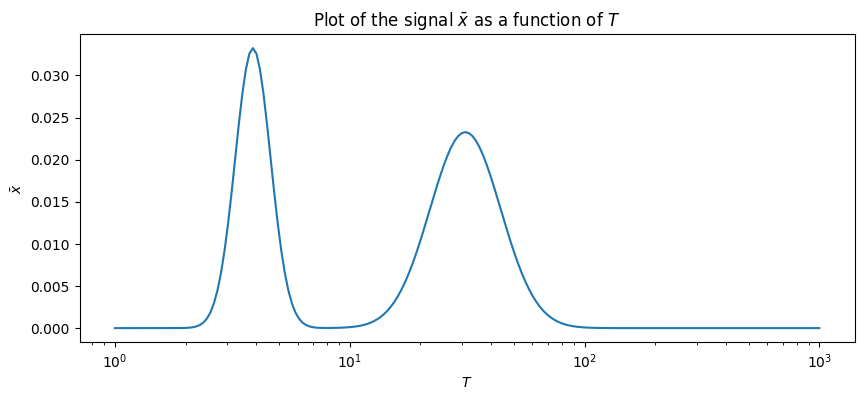

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(T, x_true)
plt.xlabel(r"$T$")
plt.ylabel(r"$\bar{x}$")
plt.title(r"Plot of the signal $\bar{x}$ as a function of $T$")
plt.xscale("log")
plt.show()

### Question 4

In [8]:
M = 50
t_min = 0
t_max = 1.5

In [9]:
t = t_min + np.arange(M) * (t_max - t_min) / (M - 1)

### Question 5

In [10]:
T_meshgrid, t_meshgrid = np.meshgrid(T, t)
print(f"Shape of T_meshgrid: {T_meshgrid.shape}, shape of t_meshgrid: {t_meshgrid.shape}")

Shape of T_meshgrid: (50, 200), shape of t_meshgrid: (50, 200)


In [11]:
K = np.exp(-T_meshgrid * t_meshgrid)
print(f"Shape of K: {K.shape}")

Shape of K: (50, 200)


### Question 6

In [12]:
z = K @ x_true
sigma = .01 * z[0]
w = np.random.normal(0, sigma, M)

# Noisy data
y = z + w

### Question 7

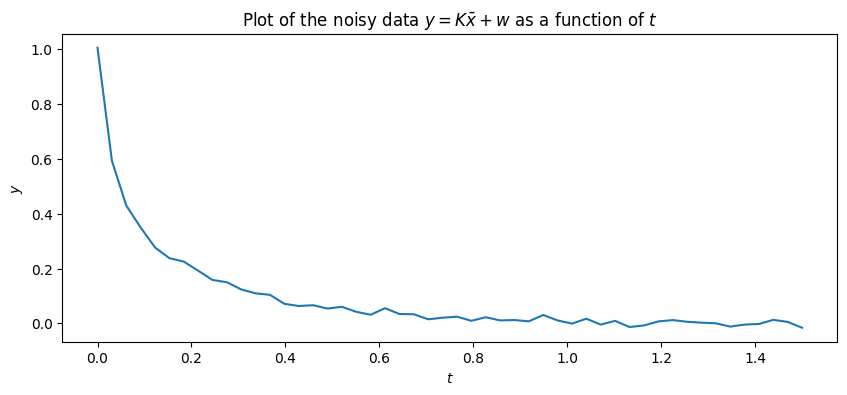

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.xlabel(r"$t$")
plt.ylabel(r"$y$")
plt.title(r"Plot of the noisy data $y = K\bar{x} + w$ as a function of $t$")
plt.show()

## Comparison of regularization strategies

### Question 1

In the following, we let 
\begin{align*}
    f :x \in \mathbb{R}^N \mapsto \frac{1}{2}\Vert Kx - y\Vert^2.
\end{align*}
Problem (4) aims to minimize $f + \beta g$ over $\mathbb{R}^N$. $f$ is convex, but not necessarily strongly convex, depending on if $K^\top K$ is positive definite or only positive semi-definite.

If $\beta = 0$, then (4) is a linear least squares problem, and admits at least one solution (e.g. $(K^\top K)^\dagger K^\top y$, where $(K^\top K)^\dagger$ is the pseudoinverse of $K^\top K$). If $K^\top K$ is positive definite, this solution is unique, and equal to $(K^\top K)^{-1} K^\top y$. If not, then (4) admits an infinite number of solutions. Let us now focus on the case where $\beta > 0$.
- **Smoothness prior:** Let $g(x) = \frac{1}{2}\Vert Dx \Vert^2$ with $D = I_N - J^{N-1}$, where J is the following circulant matrix:
\begin{align*}
    J := \begin{bmatrix}
        0 & 1 & 0 & \dots & 0 \\
        0 & 0 & 1 & \dots & 0 \\
        \vdots & & & \ddots & \vdots \\
        0 & & & & 1 \\
        1 & 0 & 0 & \dots & 0
    \end{bmatrix} \in \mathbb{R}^{N\times N}
\end{align*}
Then, (4) is a linear least squares problem with Tikhonov regularization and admits at least a solution, which is unique if and only if $K^\top K + \beta D^\top D$ is positive definite. To check that this condition is verified, let us first study the eigenvalues of $D^\top D$.

First, we have that $D^\top D = 2 I_N - J - J^{N-1}$. Letting $\omega := e^{2 i \pi / N}$, we have that the eigenvalues of $ J $ are the $\omega^k$, for $k=0,\dots,N-1$. The associated eigenvectors are $\begin{bmatrix} 1 & \omega^k & \omega^{2k} & \dots & \omega^{(N-1)k} \end{bmatrix}^\top$. This means that $D^\top D$ admits the same eigenvectors, associated with eigenvalues $P(\omega^k)$ for $k=0,\dots,N-1$, where $P(X) = 2 - X - X^{N-1}$.

For all $k\in \{0,\dots,N-1\}$ we have that
\begin{align*}
P(\omega^k) & = 2 - e^{2 i \pi k / N} - e^{2 i \pi k (N-1) / N}\\
            & = 2 - e^{2 i \pi k / N} - e^{- 2 i \pi k / N} \\
            & = 2 - 2 \cos(2\pi \frac{k}{N}) \\
            & = 0 \quad \quad\text{if and only if $k = 0$.}
\end{align*}

Thus, $\text{Ker}(D^\top D) = \text{Span}(\mathbf{1})$, where $\mathbf{1} \in \mathbb{R}^N$ is the vector whose components are all $1$.

Note that $\mathbf{1} \notin \text{Ker}(K)$. Indeed,
\begin{align*}
    \forall m \in \{1,\dots, M\}, \quad [K \mathbf{1}]^{(m)} = \sum_{n=1}^N e^{-T^{(n)} t^{(m)}} > 0.
\end{align*}
We can now check whether $K^\top K + \beta D^\top D$ is positive definite or not. Let $x \in \mathbb{R}^N$. Since $\beta > 0$, we have that
\begin{align*}
    x^\top (K^\top K + \beta D^\top D) x = 0 & \Longleftrightarrow x^\top K^\top K x = 0 \quad \text{and} \quad x^\top D^\top D x = 0 \\
                                             & \Longleftrightarrow x^\top K^\top K x = 0 \quad \text{and} \quad x \in \text{Span}(\mathbf{1}) \\
                                             & \Longleftrightarrow x^\top K^\top K x = 0 \quad \text{and} \quad \exists \lambda \in \mathbb{R}, x = \lambda \mathbf{1}  \\
                                             & \Longleftrightarrow \exists \lambda \in \mathbb{R}, x = \lambda \mathbf{1} \quad \text{and} \quad \lambda^2 \Vert K \mathbf{1}\Vert^2 = 0 \\
                                             & \Longleftrightarrow x = 0, \quad \text{since $\mathbf{1} \notin \text{Ker}(K)$.}
\end{align*}

Thus, $K^\top K + \beta D^\top D$ is positive definite, and (4) admits a unique solution.



- **Smoothness prior with constraints:** Let $g(x) = \frac{1}{2}\Vert Dx \Vert^2 + \iota_{[x_{\text{min}}, x_{\text{max}}]}(x)$. $f + \beta g$ is proper (since $x_{\text{min}} < x_{\text{max}}$), lower semi-continuous (since $[x_{\text{min}}, x_{\text{max}}]$ is closed), and coercive. Thus, (4) admits at least one solution. Since $f + \beta g$ is strongly convex (since $K^\top K + \beta D^\top D \succ 0$), this solution is unique.

- **Sparsity prior:** Let $g(x) = \Vert x \Vert_1$. $f + \beta g$ is proper, continuous and coercive, since $g$ is coercive. Thus, (4) admits at least one solution. However, this solution is generally not unique. Here is a counterexample:

Let $M=2, N = 1, K = \begin{bmatrix} 1 & 1 \end{bmatrix}, y = 1, \beta = 1/2$. In this setting, the objective can be written as 
\begin{align*}
F(x) = x^\top \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix} x - \begin{bmatrix} 1 & 1 \end{bmatrix} x + \frac{1}{2}\Vert x\Vert_1.
\end{align*}
Using the sub-differential of $F$, we get that $x$ is a minimizer of $F$ if and only if there exists $s\in\mathbb{R}^2$ such that
\begin{align*}
\forall i\in\{1,2\}, \quad x_1 + x_2 - 1 + \frac{s_i}{2} = 0 \quad \text{and} \quad  s_i \in \begin{cases} 
\{\text{sign}(x_i)\} \quad & \text{if} \quad x_i \neq 0, \\
[-1, 1] &  \text{otherwise}.
\end{cases}
\end{align*}
Thus, $F$ admits multiple minimizers (for instance $\begin{bmatrix} 1/4 & 1/4 \end{bmatrix}$ and $\begin{bmatrix} 1/8 & 3/8 \end{bmatrix}$).

### Question 2

- **Smoothness prior**: In this case, we aim to solve
\begin{align*}
    \min_{x\in\mathbb{R}^N} \; \left\{ F(x) := \frac{1}{2} \Vert Kx - y \Vert^2 + \frac{\beta}{2} \Vert Dx\Vert^2 \right\}.
\end{align*}
This problem's solution admits a closed form: $\hat{x} = (K^\top K + \beta D^\top D)^{-1} K^\top y$. However, inverting direclty $K^\top K + \beta D^\top D$ may lead to numerical instabilities when the matrix's condition number is high (this is often the case when $M < N$, which is the case for our synthetic data), and yield wrong values for $\hat{x}$. For this reason, we choose to solve this problem using gradient descent with fixed step size. This method converges to the minimizer $\hat{x}$ since $F$ is proper, convex and continuous and has a $\nu$-Lipschitzian gradient, where $\nu$ is the maximal eigenvalue of $K^\top K + \beta D^\top D$, if the step size $\gamma$ is such that $0 < \gamma < \frac{2}{\nu}$. Since $\nabla F(x) = K^\top(Kx-y) + \beta D^\top D x$, the gradient descent algorithm is:
\begin{align*}
    x_{t+1} \gets x_t - \gamma \left( K^\top(Kx_t-y) + \beta D^\top D x_t \right).
\end{align*}

- **Smoothness prior with constraints**: In this case, we aim to solve
\begin{align*}
    \min_{x\in [x_{\text{min}}, x_{\text{max}} ]^N} \; \left\{ F(x) := \frac{1}{2} \Vert Kx - y \Vert^2 + \frac{\beta}{2} \Vert Dx\Vert^2 \right\}.
\end{align*}
This problem can be solved using projected gradient descent, since $C := [x_{\text{min}}, x_{\text{max}} ]^N$ is a convex set, for which the projection has a simple closed-form expression. Indeed,
\begin{align*}
    P_C \; x = \left[ \max (x_{\text{min}}, \min(x_{\text{max}}, x_i))   \right]_{i=1,\dots,N}.
\end{align*}
Thus, the projected gradient algorithm in this setting is, for step sizes $\gamma \in (0, 2/\nu), \lambda \in (0, 2 - \gamma\nu/2),$
\begin{align*}
    & z_t \gets x_t - \gamma \left( K^\top(Kx_t-y) + \beta D^\top D x_t \right)\\
    & x_{t+1} \gets x_t + \lambda(P_C \; z_t - x_t).
\end{align*}

- **Sparsity prior**: In this case, we aim to solve
\begin{align*}
    \min_{x\in\mathbb{R}^N} \; \left\{ F(x) := \frac{1}{2} \Vert Kx - y \Vert^2 + \beta \Vert x\Vert_1 \right\}.
\end{align*}
Let $f(x) = \frac{1}{2} \Vert Kx - y \Vert^2$ and $g(x) = \beta \Vert x\Vert_1$. Since $f$ is $\nu$-Lipschitz differentiable (here, $\nu$ is the maximal eigenvalue of $K^\top K$) and $\text{prox}_g$ has a closed form expression, we can solve this problem with a Forward-Backward algorithm. 
Let $\gamma \in (0,2/\nu),  \lambda \in (0, 2 - \gamma\nu/2).$ We have:
\begin{align*}
    \text{prox}_{\gamma g}(x) = \text{sign}(x) \max\{ |x| - \gamma\beta, 0\}.
\end{align*}
The forward-backward algorithm writes:
\begin{align*}
    & z_t \gets x_t - \gamma K^\top(Kx_t-y) \\
    & x_{t+1} \gets x_t + \lambda(\text{prox}_{\gamma g}(z_t) - x_t).
\end{align*}

While we could set our step sizes $\gamma$ to the maxiaml step size values that guarantee convergence, which depend on $\nu$, we choose to set $\gamma = 10^{-3}$ in all of the following implementations, as in practical settings, estimating $\nu$ may be too computationally intensive to be done.

### Question 3 - Smoothness prior

In [14]:
D = sp.linalg.circulant(np.array([1] + [-1] + (N-2) * [0]))
D

array([[ 1,  0,  0, ...,  0,  0, -1],
       [-1,  1,  0, ...,  0,  0,  0],
       [ 0, -1,  1, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  1,  0,  0],
       [ 0,  0,  0, ..., -1,  1,  0],
       [ 0,  0,  0, ...,  0, -1,  1]])

In [15]:
def GD(y, K, beta, D, x_0, gamma, N_iter = 10000):
    x = x_0
    DT_D = D.T @ D                 # Precomputing D^T @ D to save time
    for i in range(N_iter):
        grad = K.T @ (K @ x - y) + beta * DT_D @ x
        x = x - gamma * grad
    return x

In [16]:
x_hat_smooth = GD(y = y, K = K, beta = 1e-2, D = D, x_0 = np.zeros(N), gamma = 1e-3)

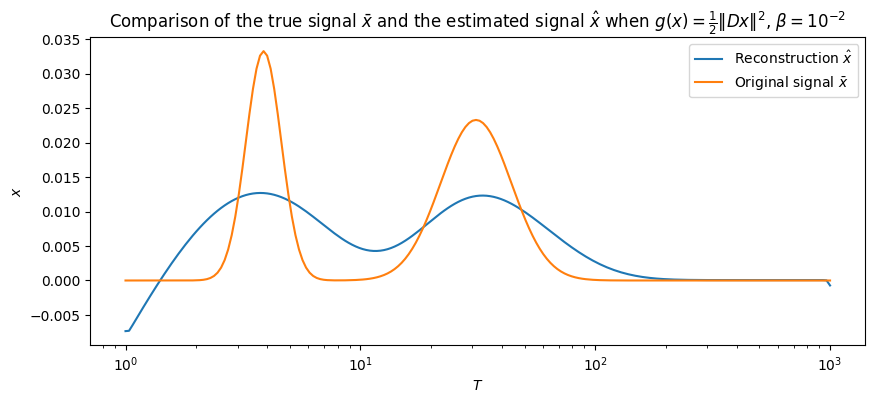

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(T, x_hat_smooth, label=r"Reconstruction $\hat{x}$")
plt.plot(T, x_true, label=r"Original signal $\bar{x}$")
plt.title(r"Comparison of the true signal $\bar{x}$ and the estimated signal $\hat{x}$ when $g(x) = \frac{1}{2}\Vert Dx\Vert^2$, $\beta = 10^{-2}$")
plt.legend()
plt.xscale("log")
plt.xlabel(r"$T$")
plt.ylabel(r"$x$")
plt.show()

### Question 3 - Smoothness prior with constraints

In [18]:
def projected_GD(y, K, beta, D, x_min, x_max, x_0, gamma, lambd, N_iter = 10000):
    x = x_0
    DT_D = D.T @ D
    for i in range(N_iter):
        grad = K.T @ (K @ x - y) + beta * DT_D @ x
        z = x - gamma * grad
        proj_z = np.maximum(np.minimum(z, x_max), x_min)
        x = x + lambd * (proj_z - x)
    return x

In [19]:
x_hat_smooth_constrained = projected_GD(y = y, K = K, beta = 1e-2, D = D, x_min = np.min(x_true), x_max = np.max(x_true), x_0 = np.zeros(N), gamma = 1e-3, lambd = 1.)

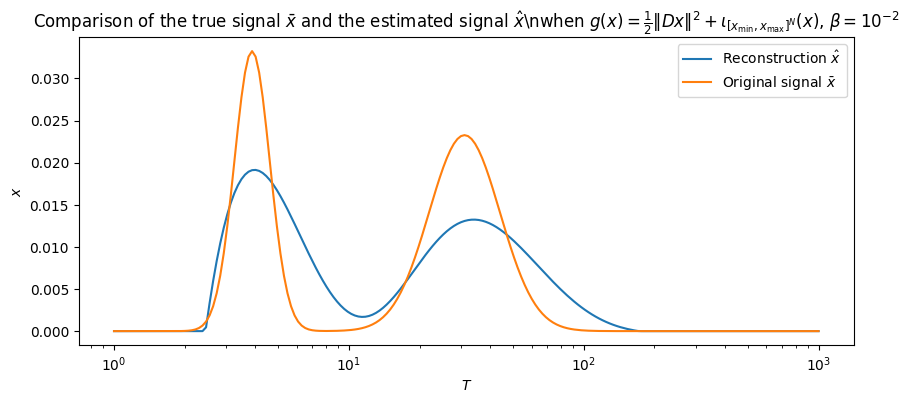

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(T, x_hat_smooth_constrained, label=r"Reconstruction $\hat{x}$")
plt.plot(T, x_true, label=r"Original signal $\bar{x}$")
plt.title(
    r"Comparison of the true signal $\bar{x}$ and the estimated signal $\hat{x}$\n"
    r"when $g(x) = \frac{1}{2}\Vert Dx\Vert^2 + \iota_{[x_{\mathrm{min}}, x_{\mathrm{max}} ]^N}(x)$, "
    r"$\beta = 10^{-2}$",
    fontsize=12,
)
plt.legend()
plt.xscale("log")
plt.xlabel(r"$T$")
plt.ylabel(r"$x$")
plt.show()

### Question 3 - Sparsity prior

In [21]:
def forward_backward(y, K, beta, x_0, gamma, lambd, N_iter = 10000):
    x = x_0
    for i in range(N_iter):
        grad = K.T @ (K @ x - y)
        z = x - gamma * grad
        prox_z = np.sign(z) * np.maximum(np.abs(z) - gamma * beta, 0)
        x = x + lambd * (prox_z - x)
    return x

In [22]:
x_hat_sparse = forward_backward(y = y, K = K, beta = 1e-1, x_0 = np.zeros(N), gamma = 1e-3, lambd = 1.)

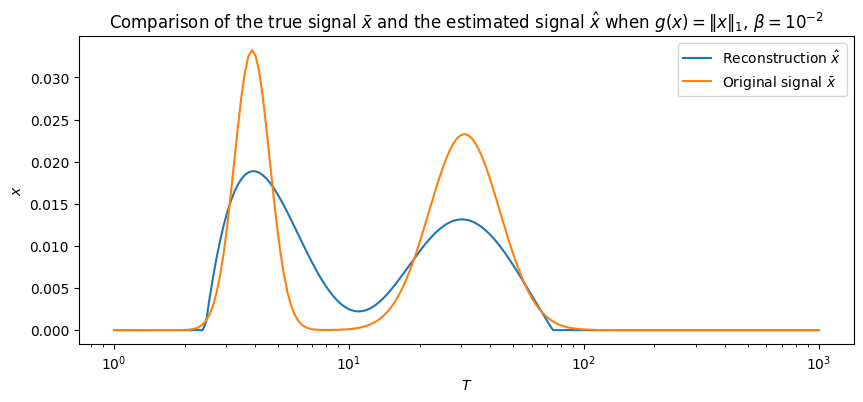

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(T, x_hat_sparse, label=r"Reconstruction $\hat{x}$")
plt.plot(T, x_true, label=r"Original signal $\bar{x}$")
plt.title(r"Comparison of the true signal $\bar{x}$ and the estimated signal $\hat{x}$ when $g(x) = \Vert x \Vert_1$, $\beta = 10^{-2}$")
plt.legend()
plt.xscale("log")
plt.xlabel(r"$T$")
plt.ylabel(r"$x$")
plt.show()

### Questions 4 & 5

In [24]:
def E(x_hat, x_true):
    return np.linalg.norm(x_hat - x_true) ** 2 / np.linalg.norm(x_true) ** 2

In [25]:
beta_grid = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.]

In [26]:
# Smoothness prior
E_smoothness_prior = []
for beta in beta_grid:
    x_hat = GD(y = y, K = K, beta = beta, D = D, x_0 = np.zeros(N), gamma = 1e-3)
    E_smoothness_prior.append(E(x_hat, x_true))

Best beta for smoothness prior: 0.1, corresponding normalized error: 0.350


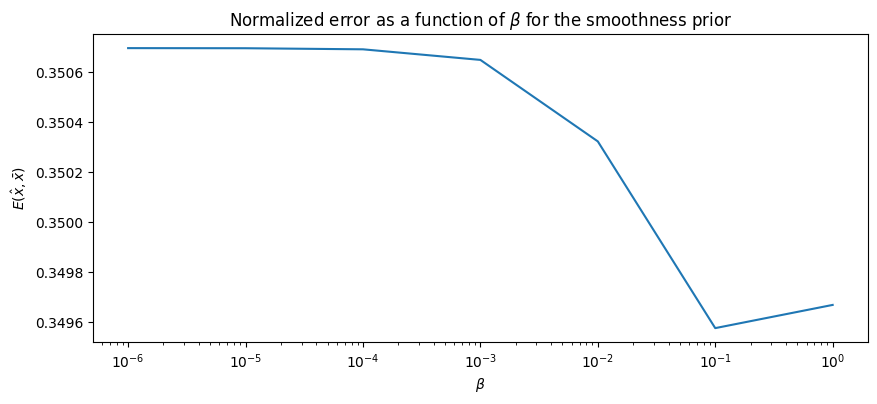

In [27]:
print(f"Best beta for smoothness prior: {beta_grid[np.argmin(E_smoothness_prior)]}, corresponding normalized error: {np.min(E_smoothness_prior) :.3f}")

plt.figure(figsize=(10, 4))
plt.title(r"Normalized error as a function of $\beta$ for the smoothness prior")
plt.plot(beta_grid, E_smoothness_prior)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E(\hat{x}, \bar{x})$")
plt.xscale("log")
plt.show()

In [28]:
# Smoothness prior + constraints
E_smoothness_constraints = []
for beta in beta_grid:
    x_hat = projected_GD(y = y, K = K, beta = beta, D = D, x_min = np.min(x_true), x_max = np.max(x_true), x_0 = np.zeros(N), gamma = 1e-3, lambd = 1.)
    E_smoothness_constraints.append(E(x_hat, x_true))

Best beta for smoothness prior with constraints: 1e-06, corresponding normalized error:  0.208


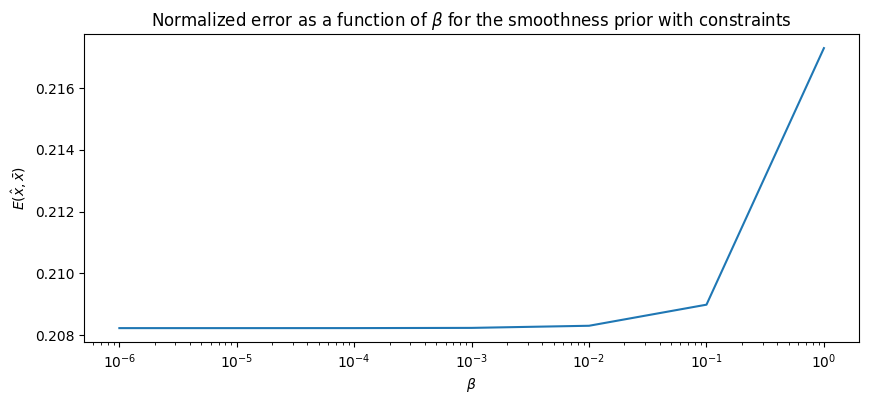

In [29]:
print(f"Best beta for smoothness prior with constraints: {beta_grid[np.argmin(E_smoothness_constraints)]}, corresponding normalized error: {np.min(E_smoothness_constraints) : .3f}")

plt.figure(figsize=(10, 4))
plt.title(r"Normalized error as a function of $\beta$ for the smoothness prior with constraints")
plt.plot(beta_grid, E_smoothness_constraints)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E(\hat{x}, \bar{x})$")
plt.xscale("log")
plt.show()

In [30]:
# Sparsity prior
E_sparse = []
for beta in beta_grid:
    x_hat = forward_backward(y = y, K = K, beta = beta, x_0 = np.zeros(N), gamma = 1e-3, lambd = 1.)
    E_sparse.append(E(x_hat, x_true))

Best beta for sparsity prior: 0.1, corresponding normalized error:  0.190


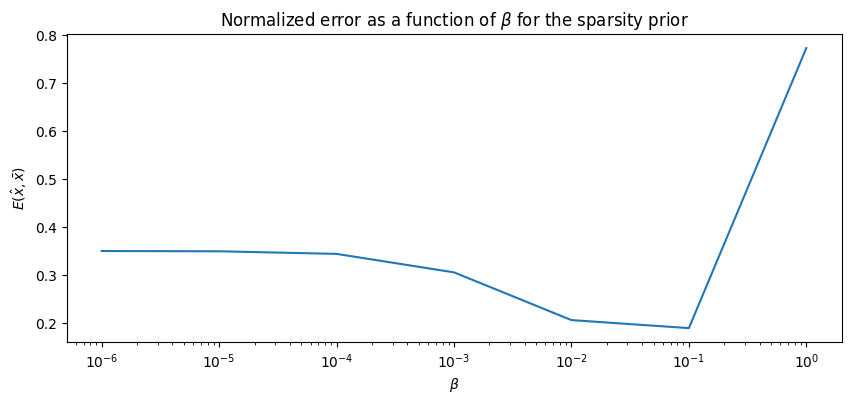

In [31]:
print(f"Best beta for sparsity prior: {beta_grid[np.argmin(E_sparse)]}, corresponding normalized error: {np.min(E_sparse) : .3f}")

plt.figure(figsize=(10, 4))
plt.title(r"Normalized error as a function of $\beta$ for the sparsity prior")
plt.plot(beta_grid, E_sparse)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E(\hat{x}, \bar{x})$")
plt.xscale("log")
plt.show()

# Reconstruction of DOSY NMR signals - Part II

### Question 1

Let us first show some properties of $\varphi$:
- $\varphi$ is continuous over $[0,+\infty)$ since $\lim_{u\rightarrow 0^+} u\log u = 0$. It is thus lower-semicontinuous over $\mathbb{R}$, since $[0,+\infty)$ is closed at $0$.
- $\varphi$ is proper since $\varphi(0) = 0$.
- $\varphi$ is differentiable over $(0,+\infty)$, where $\varphi'(u) = \log u + 1$. However, it is not differentiable at $0$, since $\lim_{u\rightarrow 0^+} \frac{u\log u}{u} = -\infty$.
- $\varphi$ is convex over $\mathbb{R}$ as it is convex over $(0,+\infty)$ (since $\varphi'(u) = \log u + 1$ is increasing), and continuous on the right at $0$.

Since $\text{ent}(x) = \sum_{i=1}^N \varphi(x^{(i)})$, we have that $\text{ent}$ is also convex, proper and lower-semicontinuous, and that it is differentiable over $(0,+\infty)^N$.

### Question 2

We assume in the following that $\beta > 0$, as the case where $\beta = 0$ has already been treated in Part I. 

Since $x \mapsto \frac{1}{2} \Vert Kx-y\Vert^2$ is convex, continuous, and its domain is $\mathbb{R}^N$, (1)'s objective is in $\Gamma_0(\mathbb{R}^N)$. Furthermore, $\text{ent}$ is coercive, since $\text{ent}(x) = + \infty$ if $x \notin [0,+\infty)^N$, and $\lim_{u\rightarrow + \infty} u\log u = +\infty$, and $x \mapsto \frac{1}{2} \Vert Kx-y\Vert^2$ is non-negative. Thus, (1)'s objective is also coercive, and the optimization problem has a solution.

Furthermore, (1)'s objective is strongly convex, since $\text{ent}$ is strongly convex. Indeed, the Hessian of $\text{ent}$ at $x \in (0,+\infty)^N$ is a diagonal matrix whose coefficients are $\varphi''(x^{(n)}) = \frac{1}{x^{(n)}} > 0$. Thus, the solution to the optimization problem is unique.


### Question 3

Let $x\in\mathbb{R}$. We have that
\begin{align*}
\text{prox}_\varphi(x) & = \argmin_{y \in \mathbb{R}} \; \left\{\frac{1}{2}(x-y)^2 + \varphi(y) \right\}\\
                       & = \argmin_{y \geqslant 0} \; \left\{\frac{1}{2}(x-y)^2 + \varphi(y) \right\}
\end{align*}
The minimum of $y\mapsto \frac{1}{2}(x-y)^2 + \varphi(y)$ over $(0,+\infty)$ is reached at $y$ such that $y - x + \log y + 1 = 0$, i.e. such that $ye^y = e^{x-1}$. Thus it is attained at $y=W(e^{x-1})$, where $W$ is the Lambert $W$-function. Since $y\mapsto \frac{1}{2}(x-y)^2 + \varphi(y)$ is decreasing near $0$ (since $\lim_{u\rightarrow 0^+} \frac{u\log u}{u} = -\infty$), the minimum over $(0,+\infty)$ is the minimum over $[0,+\infty)$.

We thus have:
\begin{align*}
\text{prox}_\varphi(x) & = W(e^{x-1}).
\end{align*}

Thus, for all $x\in\mathbb{R}^N$,
\begin{align*}
\forall n \in \{1,\dots, N \}, \quad \text{prox}_\text{ent}(x)^{(n)} & = W\left(\exp(x^{(n)}-1)\right).
\end{align*}

### Question 4

- **Forward-Backward algorithm:** Since $f : x \mapsto \frac{1}{2} \Vert Kx - y\Vert^2$ is differentiable with a $\nu$-Lipschitz gradient (where $\nu>0$ is the maximal eigenvalue of $K^\top K$), the optimization problem can be solved using a Forward-Backward algorithm with constant stepsize $\gamma \in (0,2/\nu)$ and $\lambda \in (0,2 - \gamma\nu/2)$:
\begin{align*}
    & z_t \gets x_t - \gamma (K^\top K x_t - K^\top y)\\
    & x_{t+1} \gets x_t + \lambda(\text{prox}_{\beta\gamma\text{ent}}(z_t) - x_t),
\end{align*}
where, for all $\tau > 0$, for all $x \in \mathbb{R}^N$, we have
\begin{align*}
\forall n \in \{1,\dots,N\}, \quad \text{prox}_{\tau \text{ent}} (x)^{(n)} = \tau  W\left(\frac{1}{\tau}\exp\left(\frac{x^{(n)}}{\tau} - 1\right)\right).
\end{align*}
This can be shown using a similar method to the one used in Question 3.

- **Douglas-Rachford algorithm:** Letting $\gamma > 0$ , $\lambda \in (0,2)$, the following Douglas-Rachford algorithm converges to the optimization problem's soltuion:
  \begin{align*}
    & u_t \gets \text{prox}_{\gamma f}(x_t)\\
    & z_t \gets \text{prox}_{\beta\gamma\text{ent}}(2 u_t - x_t)\\
    & x_{t+1} \gets x_t + \lambda(z_t - u_t)
\end{align*}
where
\begin{align*}
 \text{prox}_{\gamma f}(x) = (I_N + \gamma K^\top K)^{-1}(x + \gamma K^\top y)
\end{align*}

### Question 5

Directly applying the closed form expression of the proximal operator of $\texttt{ent}$ may lead to numerical issues, as it computes the exponential of large numbers, which may go beyond the float64 range. To circumvent this issue, we use an asymptotic expansion of the $W$ function, which we can use as an approximation of $W(x)$ for large values of $x$:
\begin{align*}
W(x) = \log x + O_{x\rightarrow +\infty}(\log \log x)
\end{align*}

In [32]:
from scipy.special import lambertw

def prox_ent(z, tau):
    """ 
    Returns the proximal operator of the tau*ent at z, using the approximation for values of z/tau > 10
    """
    arg = z/tau
    mask = (arg > 10.) * 1.

    arg_small = arg * (1 - mask)
    W_small = tau * np.real(lambertw(np.exp(arg_small - 1) / tau))

    arg_big = arg * mask
    W_big = tau * arg_big - tau - tau * np.log(tau)

    return W_small * (1 - mask) + W_big * mask

In [33]:
def forward_backward_W(y, K, beta, x_0, lambd, gamma,  N_iter = 10000):
    x = x_0
    for i in range(N_iter):
        grad = K.T @ (K @ x - y)
        z = x - gamma * grad
        prox_z = prox_ent(z, beta*gamma)
        x = x + lambd * (prox_z - x)
    return x

In [34]:
def douglas_rachford(y, K, beta, x_0, lambd, gamma, N_iter = 10000):
    x = x_0
    N = len(x_0)
    inv_prox = np.linalg.inv(np.eye(N) + gamma * K.T @ K)
    for i in range(N_iter):
        u = inv_prox @ (x + gamma * K.T @ y)
        z = prox_ent(2 * u - x, beta*gamma)
        x = x + lambd * (z - x)
    return x

In [35]:
beta = 1e-2  # Regularization parameter
lambd = 1. # Relaxation parameter
gamma = 1e-3  # Step size

# Forward-Backward solution
fb_solution = forward_backward_W(y, K, beta, np.zeros(N), lambd, gamma)

# Douglas-Rachford solution
dr_solution = douglas_rachford(y, K, beta, np.zeros(N), lambd, gamma)

# Performance evaluation
fb_error = E(fb_solution, x_true)
dr_error = E(dr_solution, x_true)

print("Forward-Backward reconstruction error:", fb_error)
print("Douglas-Rachford reconstruction error:", dr_error)


Forward-Backward reconstruction error: 0.22948273049269952
Douglas-Rachford reconstruction error: 0.1823148164020017


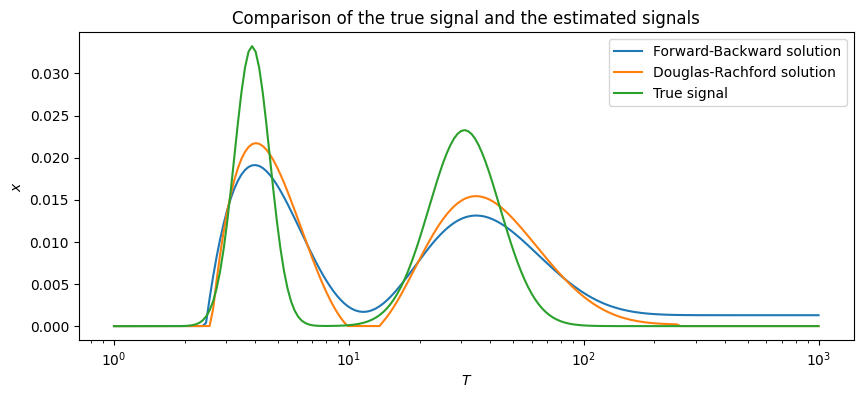

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(T, fb_solution, label="Forward-Backward solution")
plt.plot(T, dr_solution, label="Douglas-Rachford solution")
plt.plot(T, x_true, label="True signal")
plt.legend()
plt.xscale("log")
plt.xlabel(r"$T$")
plt.ylabel(r"$x$")
plt.title("Comparison of the true signal and the estimated signals")
plt.show()

### Question 6

In [40]:
betas = np.logspace(-6, -1, 6)

errors_fb = []
errors_dr = []

for beta in betas:
    x_hat = forward_backward_W(y = y, K = K, beta = beta, x_0 = np.zeros(N), lambd = 1, gamma= 1e-3)
    errors_fb.append(E(x_hat, x_true))
    x_hat = douglas_rachford(y = y, K = K, beta = beta, x_0 = np.zeros(N), lambd = 1, gamma= 1e-3)
    errors_dr.append(E(x_hat, x_true))

Best beta for Forward-Backward algorithm: 1e-06, corresponding normalized error:  0.208


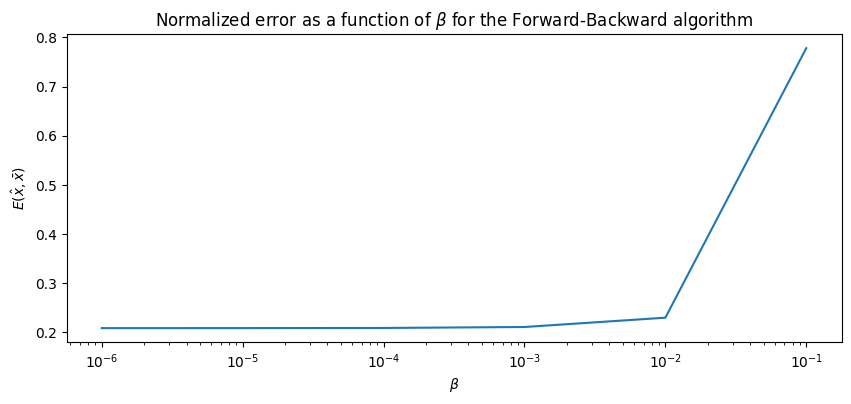

In [41]:
print(f"Best beta for Forward-Backward algorithm: {betas[np.argmin(errors_fb)]}, corresponding normalized error: {np.min(errors_fb) : .3f}")

plt.figure(figsize=(10, 4))
plt.title(r"Normalized error as a function of $\beta$ for the Forward-Backward algorithm")
plt.plot(betas, errors_fb)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E(\hat{x}, \bar{x})$")
plt.xscale("log")
plt.show()

Best beta for Douglas-Rachford algorithm: 1e-06, corresponding normalized error:  0.159


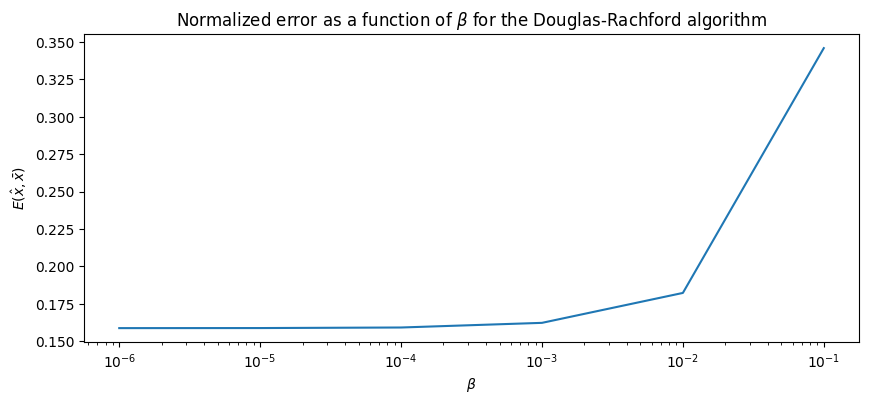

In [42]:
print(f"Best beta for Douglas-Rachford algorithm: {betas[np.argmin(errors_dr)]}, corresponding normalized error: {np.min(errors_dr) : .3f}")

plt.figure(figsize=(10, 4))
plt.title(r"Normalized error as a function of $\beta$ for the Douglas-Rachford algorithm")
plt.plot(betas, errors_dr)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E(\hat{x}, \bar{x})$")
plt.xscale("log")
plt.show()

### Question 7

We report in the following table the reconstruction errors obtained for each method:
| Method                                                         | Normalized Quadratic Error |  $\beta$  |
|----------------------------------------------------------------|:--------------------------:|:---------:|
| Smoothness Prior (Gradient Descent)                            |           $0.350$          | $10^{-1}$ |
| Smoothness Prior with Constraints (Projected Gradient Descent) |           $0.208$          | $10^{-6}$ |
| Sparsity Prior (Forward-Backward)                              |           $0.190$          | $10^{-1}$ |
| Maximum Entropy Regularization (Forward-Backward)              |           $0.208$          | $10^{-6}$ |
| Maximum Entropy Regularization (Douglas-Rachford)              |           $0.159$          | $10^{-6}$ |

Out of all the tested methods, the Maximum Entropy Regularization method, implemented with the Douglas-Rachford algorithm, yields the best reconstruction error. However, keep in mind that other hyperparameters than $\beta$ were not fitted for each algorithm, meaning that the performance of some algorithms could be improved.

### Question 8

Solving
\begin{align*}
    \min_{x \in \mathbb{R}^N} \text{ent}(x) \quad \text{s.t.} \quad \Vert Kx - y\Vert^2 \leqslant \eta M \sigma^2,
\end{align*}
can be done with the PPXA+ algorithm. Indeed, by letting $C := \{z \in \mathbb{R}^M: \Vert z - y\Vert^2 \leqslant \eta M \sigma^2\}$, the problem can be rewritten as
\begin{align*}
    \min_{x \in \mathbb{R}^N} \text{ent}(x) + \iota_C(Kx),
\end{align*}
or equivalently,
\begin{align*}
    \min_{x \in \mathbb{R}^{N}} g_1(L_1 x) + g_2(L_2 x)
\end{align*}
where $g_1 = \text{ent}$, $g_2 = \iota_C$, $L_1 = I_N$ and $L_2 = K$. We have that $g_1\in \Gamma_0(\mathbb{R}^N)$, $g_2\in \Gamma_0(\mathbb{R}^M)$, $I_N \in \mathcal{B}(\mathbb{R}^N,\mathbb{R}^N)$, $K \in \mathcal{B}(\mathbb{R}^N,\mathbb{R}^M)$. Thus, the following PPXA+ algorithm converges to the minimizer of (4) for any $\gamma > 0, \lambda \in (0,2)$:
\begin{align*}
& z_{t,i} \gets \text{prox}_{\gamma{g_i}}(x_{t,i}) \quad \forall i \in \{1,2\}\\
& c_t \gets (I_N + K^\top K)^{-1} (z_{t,1} + K^\top z_{t,2})\\
& x_{t+1, i} \gets x_{t, i} + \lambda(L_i(2c_t - v_t) - z_{t,i}) \quad \forall i \in \{1,2\}\\
& v_{t+1} \gets v_t + \lambda(c_t - v_t)
\end{align*}
where
\begin{align*}
    \text{prox}_{\gamma\iota_C}(x) = \text{proj}_C(x)
\end{align*}

In [44]:
def proj_C(z, y, radius):
    norm_diff = np.linalg.norm(z - y)
    if norm_diff <= radius:
        return z
    else:
        return y + radius * (z - y) / norm_diff

def PPXA_plus(y, K, eta, sigma, gamma, lambd, x_1_0, x_2_0, v_0, N_iter=10000):
    x_1 = x_1_0
    x_2 = x_2_0
    v = v_0
    M, N = K.shape
    inverse = np.linalg.inv(np.eye(N) + K.T @ K)

    for _ in range(N_iter):
        z_1 = prox_ent(x_1, gamma)
        z_2 = proj_C(x_2, y, np.sqrt(eta * M) * sigma)
        c = inverse @ (z_1 + K.T @ z_2)
        x_1 = x_1 + lambd * (2 * c - v - z_1)
        x_2 = x_2 + lambd * (2 * K @ c - K @ v - z_2)
        v = v + lambd * (c - v)
    
    return v

In [105]:
x_1_0 = np.zeros(N)
x_2_0 = np.zeros(M)
v_0 = np.zeros(N)

eta = 3.5
gamma = 1e-3
lambd = 1.

N_iter = 10000

# Solve the optimization problem
x_star = PPXA_plus(y, K, eta, sigma, gamma, lambd, x_1_0, x_2_0, v_0, N_iter)

In [106]:
print("PPXA+ reconstruction error:", E(x_star, x_true))

PPXA+ reconstruction error: 0.6186501170662766


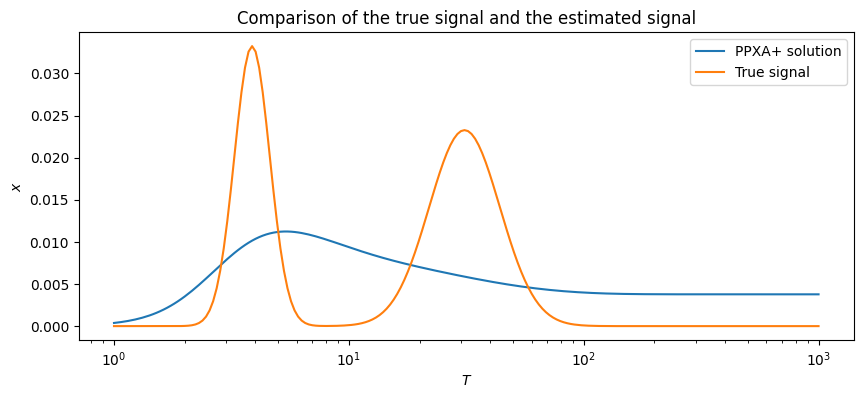

In [107]:
plt.figure(figsize=(10, 4))
plt.plot(T, x_star, label="PPXA+ solution")
plt.plot(T, x_true, label="True signal")
plt.legend()
plt.xscale("log")
plt.xlabel(r"$T$")
plt.ylabel(r"$x$")
plt.title("Comparison of the true signal and the estimated signal")
plt.show()